# Cluster LOCO Split with toy datasets

## Interlaced moon toy example: top panel

In [2]:
import sys
sys.path.append('../')
from simulations import make_interlaced_halfmoons_3feat
from clim.data_splitting import Cluster_LOCO_Split
from clim.utils import hinge_error
from benchmarking import c_SHAP, PBFI, LRP_score, feature_imp_cluster, LOCO_silhouette, GlobalStability

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
base_colors = {
    "pbfi": "#277da1",
    "lrp": "#577590",
    "impacc": "#43aa8b",
    "cluster_loco_split": "#f9c74f",
    "cluster_locomp": "#f8961e",
    "cluster_loco_rampart": "#f94144",
    "perm_feat_imp": "#e377c2",
    "shapley": "#780000",
}
palette = list(base_colors.values())
sns.set_palette(palette)
palette = sns.color_palette(list(base_colors.values()))

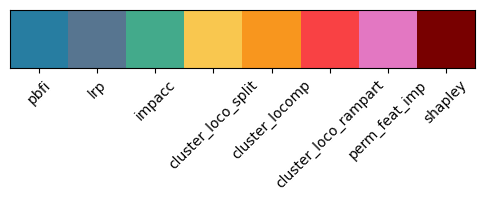

In [4]:
plt.figure(figsize=(6,1))
plt.imshow([palette])
plt.yticks([])
plt.xticks(range(len(base_colors)), base_colors.keys(), rotation=45)
plt.show()

In [5]:
def generate_non_gaussian(n_samples, seed=0):
    X, y = make_interlaced_halfmoons_3feat(n_per_class=n_samples//3, noise_xy=0.07, 
            noise_f3=0.1, seed=seed, f3_mode="nonlinear", f3_offsets=(0.8, -0.1, 0.35))
    X_perm = np.concatenate([np.random.uniform(low=-1, high=2, size=(X.shape[0],1)),np.random.uniform(low=-1, high=2, size=(X.shape[0],1))], axis=1)
    X = np.concatenate([X, X_perm], axis=1)
    return X, y

In [6]:
# Reorder columns so that first feature most important, then 2nd then 3rd.
n, seed = 1200, 24
X, y = generate_non_gaussian(n_samples=n, seed=seed)
X = X[:, [1, 0, 2, 3, 4]]

/burg/morphogenomics-lab/users/grp_tmpdir/ipykernel_1179196/2512175349.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


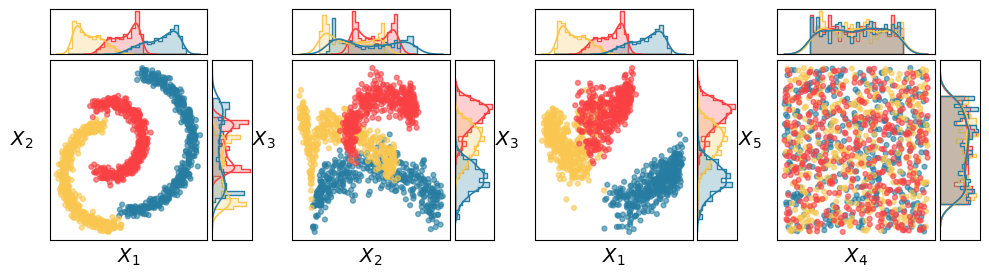

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.colors import ListedColormap
import seaborn as sns

palette = list(base_colors.values())
sns.set_palette(palette)
palette = sns.color_palette(list(base_colors.values()))


facecolor = "white"

idx = np.arange(5) # [1, 2, 0, 3, 4]
pairs = [
    (idx[0], idx[1], r"$\bf{Harder: }$" + f"Without feature {idx[2]+1}" + "\n" + rf"Signal features ($X_{{{idx[0]+1}}}, X_{{{idx[1]+1}}}$)"),
    (idx[1], idx[2], r"$\bf{Moderate: }$" +  f"Without feature {idx[0]+1}" + "\n" +rf"Signal features ($X_{{{idx[1]+1}}}, X_{{{idx[2]+1}}}$)"),
    (idx[0], idx[2], r"$\bf{Easier: }$" + f"Without feature {idx[1]+1}" + "\n" +rf"Signal features ($X_{{{idx[0]+1}}}, X_{{{idx[2]+1}}}$)"),
    (idx[3], idx[4], rf"Noise features $X_{{{idx[3]+1}}}, X_{{{idx[4]+1}}}$"),
]

# ---- consistent label order + colors
labels = np.sort(np.unique(y))
K = len(labels)
colors = [palette[0], palette[3], palette[5]]
color_map = {lab: col for lab, col in zip(labels, colors)}

lab_to_idx = {lab: i for i, lab in enumerate(labels)}
y_idx = np.vectorize(lab_to_idx.get)(y)
cmap = ListedColormap(colors)

fig = plt.figure(figsize=(12, 3))
outer = GridSpec(1, len(pairs), figure=fig, wspace=0.2)

for i, (ix, iy, title) in enumerate(pairs):
    inner = GridSpecFromSubplotSpec(
        2, 2, subplot_spec=outer[i],
        height_ratios=[1, 4],
        width_ratios=[4, 1],
        hspace=0.05,
        wspace=0.05
    )

    ax_histx = fig.add_subplot(inner[0, 0])
    ax_scatter = fig.add_subplot(inner[1, 0])
    ax_histy = fig.add_subplot(inner[1, 1])
    
    # ---- Scatter
    ax_scatter.scatter(X[:, ix], X[:, iy],
        c=y_idx, cmap=cmap, vmin=-0.5, vmax=K - 0.5,
        s=12, alpha=0.6)
    ax_scatter.set_xlabel(rf"$X_{{{ix+1}}}$", fontsize=14)
    ax_scatter.set_ylabel(rf"$X_{{{iy+1}}}$", labelpad=20, rotation=0, fontsize=14)
    ax_scatter.set_facecolor(facecolor)

    # ---- Marginal hist + KDE (cluster-colored)
    sns.histplot(x=X[:, ix], hue=y, hue_order=labels, 
        palette=color_map, bins=30, stat="density", common_norm=False,
        element="step", fill=True, alpha=0.25, legend=False, ax=ax_histx)
    sns.kdeplot(x=X[:, ix], hue=y, 
        hue_order=labels, palette=color_map, common_norm=False, legend=False,
        linewidth=1.2, ax=ax_histx)

    sns.histplot(y=X[:, iy], hue=y, 
        hue_order=labels, palette=color_map, bins=30, stat="density", common_norm=False,
        element="step", fill=True, alpha=0.25, legend=False, ax=ax_histy)
    sns.kdeplot(y=X[:, iy], hue=y, 
        hue_order=labels, palette=color_map, common_norm=False, legend=False,
        linewidth=1.2, ax=ax_histy)

    for a in (ax_histx, ax_histy, ax_scatter):
        a.set_xticks([])
        a.set_yticks([])

    # remove marginal axis labels (seaborn may add them)
    ax_histx.set_xlabel(""); ax_histx.set_ylabel("")
    ax_histy.set_xlabel(""); ax_histy.set_ylabel("")

fig.tight_layout()
fig.savefig('./figures/fig1_a.pdf', bbox_inches='tight')

## Feature importances: bottom panel

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

In [11]:
K = 3
print('KMeans based methods')
pbfi = PBFI(X, KMeans(n_clusters=K,random_state=42))
lrp = LRP_score(X, K=K)

km = KMeans(n_clusters=3, random_state=42).fit(X)
print('Permutation based methods')
perm_feat = feature_imp_cluster(km, X)['featureImp'].values
shap_vals, _ = c_SHAP(X=X, K=3, method='perm', X_reference=X).get_model_wide_importance()


KMeans based methods


/burg-archive/stats/users/cmh2277/ClusterLOCO/paper_figures/../benchmarking/neuralized_kmeans.py:65: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  z = model.W[c] * (x - 0.5 * (model.centroids[[c]] + model.centroids[knc]))


Permutation based methods


In [13]:
from sklearn.preprocessing import StandardScaler
from clim.models import BaseSpectralClustering
from sklearn.ensemble import RandomForestClassifier

clusterer = BaseSpectralClustering(n_clusters=K)
perm_feat_sp = feature_imp_cluster(clusterer.fit(X), X)['featureImp'].values

print('LOCO style scores')
silhouette_delta = LOCO_silhouette(clusterer, X)
silhouette_km = LOCO_silhouette(km, X)

LOCO style scores


In [14]:
X_tr, X_ca, y_tr, y_ca = train_test_split(X, y, test_size=0.5, shuffle=True)
gen2_km =  Cluster_LOCO_Split(X_tr, X_ca, model=km, clf = RandomForestClassifier(), K=3, seed=234, error_metric=None, n_jobs=-1)
gen2 = Cluster_LOCO_Split(X_tr, X_ca, model=clusterer, clf = RandomForestClassifier(), K=3, seed=234, error_metric=None, n_jobs=-1)

In [15]:
from sklearn.metrics import adjusted_rand_score
sp_labels, km_labels = clusterer.fit_predict(X), km.fit_predict(X)
ari_spectral = adjusted_rand_score(sp_labels, y)
ari_kmeans = adjusted_rand_score(km_labels, y)

In [16]:
print(f'ARI Spectral: {ari_spectral:.2f}, \nARI KMeans: {ari_kmeans:.2f}')

ARI Spectral: 0.99, 
ARI KMeans: 0.17


In [17]:
g = GlobalStability(X, clusterer, n_clusters=K, error_metric=None, seed=42)
g_km = GlobalStability(X, km, n_clusters=K, error_metric=None, seed=42)
stab_km = g_km.stability(B=5, ratio=0.3, method='model-explorer')
stab = g.stability(B=5, ratio=0.3, method='model-explorer')

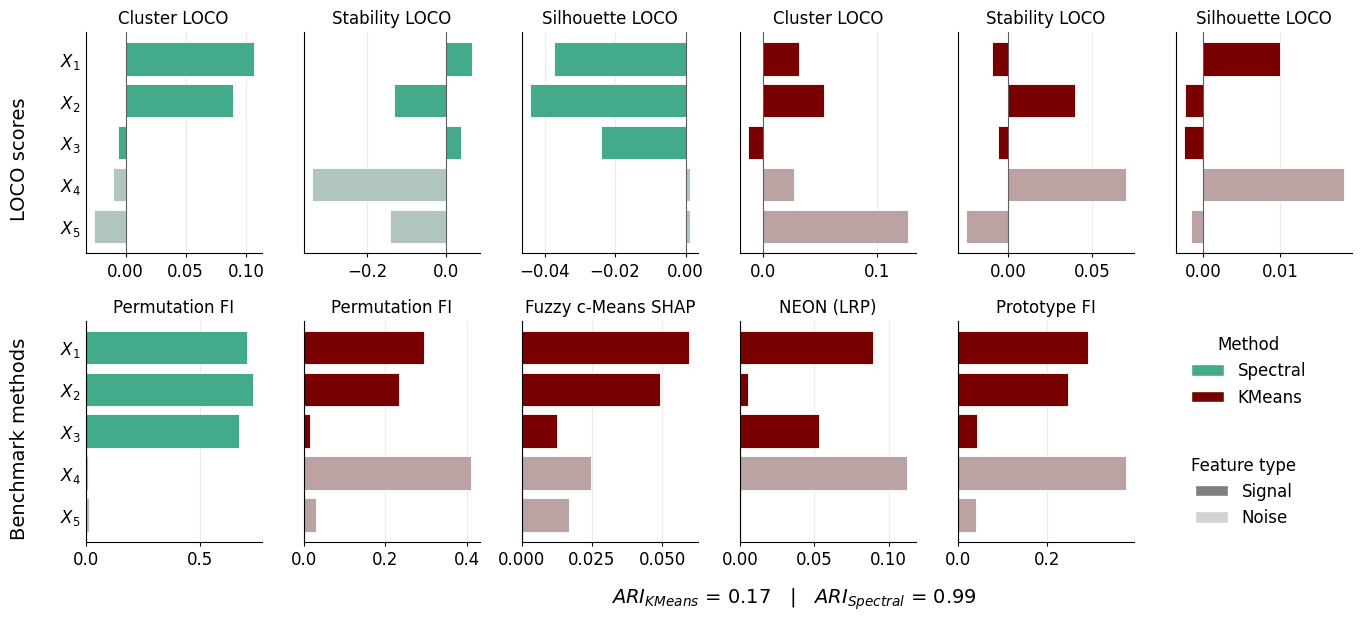

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

def add_ari_badge(ax, ari_km, ari_sp, loc=(0.98, 0.98), fontsize=12):
    txt = rf"ARI$_{{KMeans}}$={ari_km:.2f}" + "\n" + rf"ARI$_{{Spectral}}$={ari_sp:.2f}"
    ax.text(loc[0], loc[1], txt,
        transform=ax.transAxes, ha="right", va="top", fontsize=fontsize,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", edgecolor="0.8", alpha=0.9))

# ---------- style helpers ----------
def mix_with_grey(color, mix=0.80):
    rgb = np.array(mcolors.to_rgb(color))
    grey = np.array([0.8, 0.8, 0.8])
    return tuple((1 - mix) * rgb + mix * grey)

def row_min_max(arr_list):
    vals = np.concatenate([np.asarray(a).reshape(-1) for a in arr_list])
    vmin = np.nanmin(vals)
    vmax = np.nanmax(vals)
    span = vmax - vmin
    pad = 0.08 * span if span > 0 else 0.5
    return vmin - pad, vmax + pad

def barh_signal_noise(ax, values, base_color, n_signal=3, sort=False):
    """
    Horizontal bars with signal dims colored, noise dims grey-tinted.
    """
    v = np.asarray(values).reshape(-1)
    d = v.size
    idx = np.arange(d)
    if sort:
        idx = np.argsort(v)[::-1]  # descending
    v = v[idx]
    colors = []
    for k in range(d):
        orig_feat = idx[k]
        if orig_feat < n_signal:
            colors.append(base_color)                   # true signal
        else:
            colors.append(mix_with_grey(base_color))   # noise

    ax.barh(np.arange(d), v, color=colors, edgecolor="white", linewidth=0.6)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.25, linewidth=0.8)
    ax.set_axisbelow(True)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return idx

# ---------- titles without method names ----------
titles = ["Cluster LOCO", "Stability LOCO", "Silhouette LOCO",
    "Cluster LOCO", "Stability LOCO", "Silhouette LOCO",
    "Permutation FI", "Permutation FI", "Fuzzy c-Means SHAP",
    "NEON (LRP)", "Prototype FI"]

arrays = [gen2[0], stab, silhouette_delta,
          gen2_km[0], stab_km, silhouette_km,
          perm_feat_sp, perm_feat, shap_vals, lrp, pbfi]

# ---------- method for each panel ----------
# Spectral vs KMeans assignment for each subplot
methods = ["Spectral", "Spectral", "Spectral", 
           "KMeans", "KMeans", "KMeans",
            "Spectral", "KMeans", "KMeans", "KMeans", "KMeans"]

# method colors
method_colors = {"Spectral": palette[2],  # blue
                "KMeans":   palette[7],   # orange
}

# shared row limits
row0_xlim = row_min_max(arrays[:5])
row1_xlim = row_min_max(arrays[5:])

d = len(arrays[0])
n_signal = 3
sort_features = False

# ---------- plot ----------
plt.rcParams.update({"font.size": 12, "axes.titlesize": 12, "axes.labelsize": 12})
fig, axes = plt.subplots(2, 6, figsize=(16, 6.2))

for k, ax in enumerate(axes.flat):
    if k >= len(arrays):   # last cell reserved for legend
        ax.axis("off")
        continue
        
    base_color = method_colors[methods[k]]
    idx_map = barh_signal_noise(ax, arrays[k], base_color=base_color, n_signal=n_signal, sort=sort_features)

    ax.set_title(titles[k], pad=6)
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)

    if k % 6 == 0:
        ax.set_yticks(np.arange(d))
        if sort_features:
            ax.set_yticklabels([rf"$X_{{{i+1}}}$" for i in idx_map])
        else:
            ax.set_yticklabels([rf"$X_{{{i+1}}}$" for i in range(d)])
    else:
        ax.set_yticks(np.arange(d))
        ax.set_yticklabels([])
    
    ax.tick_params(axis="x", length=3)
    ax.tick_params(axis="y", length=0)

# row labels
fig.text(0.01, 0.73, "LOCO scores", rotation=90, va="center", ha="left", fontsize=14)
fig.text(0.01, 0.28, "Benchmark methods", rotation=90, va="center", ha="left", fontsize=14)

# ---------- legends ----------
legend_ax = axes[1,5]  # bottom-right cell
legend_ax.axis("off")

method_handles = [Patch(facecolor=method_colors["Spectral"], edgecolor="white", label="Spectral"),
                  Patch(facecolor=method_colors["KMeans"], edgecolor="white", label="KMeans")]

feature_handles = [Patch(facecolor="grey", edgecolor="white", label="Signal"),
                   Patch(facecolor="lightgrey", edgecolor="white", label="Noise")]

legend1 = legend_ax.legend(handles=method_handles, title="Method", loc="upper left", frameon=False, fontsize=12)
legend_ax.add_artist(legend1)
legend_ax.legend(handles=feature_handles, title="Feature type", loc="lower left", frameon=False, fontsize=12)

# ARI text
fig.text(0.5, 0.02, rf"$ARI_{{KMeans}}$ = {ari_kmeans:.2f}   |   $ARI_{{Spectral}}$ = {ari_spectral:.2f}",
    ha="center", va="center", fontsize=14)

# leave room on right for legend
fig.tight_layout(rect=[0.03, 0.04, 0.86, 1])
# fig.savefig("./figures/simulation_1_FI.pdf", bbox_inches="tight")
plt.show()

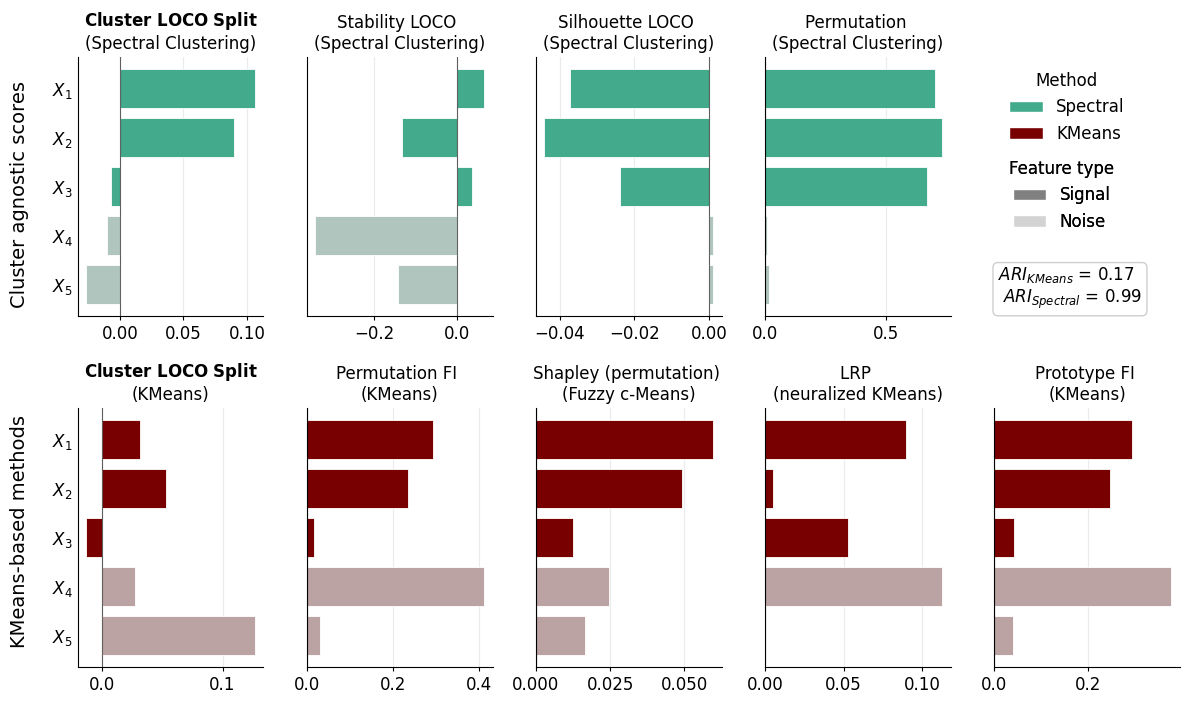

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# ---------- helpers ----------
def mix_with_grey(color, mix=0.80):
    rgb = np.array(mcolors.to_rgb(color))
    grey = np.array([0.8, 0.8, 0.8])
    return tuple((1 - mix) * rgb + mix * grey)

def row_min_max(arr_list):
    vals = np.concatenate([np.asarray(a).reshape(-1) for a in arr_list])
    vmin = np.nanmin(vals)
    vmax = np.nanmax(vals)
    span = vmax - vmin
    pad = 0.08 * span if span > 0 else 0.5
    return vmin - pad, vmax + pad

def barh_signal_noise(ax, values, base_color, n_signal=3, sort=False):
    """
    Horizontal bars with signal dims colored, noise dims grey-tinted.
    """
    v = np.asarray(values).reshape(-1)
    d = v.size

    idx = np.arange(d)
    if sort:
        idx = np.argsort(v)[::-1]

    v = v[idx]

    colors = []
    for k in range(d):
        orig_feat = idx[k]
        if orig_feat < n_signal:
            colors.append(base_color)
        else:
            colors.append(mix_with_grey(base_color))

    ax.barh(np.arange(d), v, color=colors, edgecolor="white", linewidth=0.6)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.25, linewidth=0.8)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    return idx

# ---------- titles / arrays / methods ----------
# Top row: 4 plots
titles_top = [r"$\bf{Cluster \ LOCO \ Split}$"+"\n(Spectral Clustering)",
                "Stability LOCO \n(Spectral Clustering)", 
                "Silhouette LOCO \n(Spectral Clustering)",
                "Permutation \n(Spectral Clustering)"]
arrays_top = [gen2[0], stab, silhouette_delta, perm_feat_sp]
methods_top = ["Spectral", "Spectral", "Spectral", "Spectral"]

# Bottom row: 4 plots (Permutation FI moved here)
titles_bottom = [r"$\bf{Cluster \ LOCO \ Split}$"+"\n(KMeans)", 
                 "Permutation FI \n(KMeans)", "Shapley (permutation) \n(Fuzzy c-Means)", 
                 "LRP \n(neuralized KMeans)", "Prototype FI \n(KMeans)"]
arrays_bottom = [gen2_km[0], perm_feat, shap_vals, lrp, pbfi]
methods_bottom = ["KMeans", "KMeans", "KMeans", "KMeans", "KMeans"]

# ---------- colors ----------
method_colors = {"Spectral": palette[2], "KMeans": palette[7]}

# shared row limits
row0_xlim = row_min_max(arrays_top)
row1_xlim = row_min_max(arrays_bottom)

d = len(arrays_top[0])
n_signal = 3
sort_features = False

# ---------- plot ----------
plt.rcParams.update({"font.size": 12, "axes.titlesize": 12, "axes.labelsize": 12})

fig, axes = plt.subplots(2, 5, figsize=(12, 7.5))

# ---------- first row: 4 plots ----------
for k in range(4):
    ax = axes[0, k]
    base_color = method_colors[methods_top[k]]
    idx_map = barh_signal_noise(ax, arrays_top[k], base_color=base_color, n_signal=n_signal, sort=sort_features)

    ax.set_title(titles_top[k], pad=6)
    # ax.set_xlim(*row0_xlim)
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)

    if k == 0:
        ax.set_yticks(np.arange(d))
        if sort_features:
            ax.set_yticklabels([rf"$X_{{{i+1}}}$" for i in idx_map])
        else:
            ax.set_yticklabels([rf"$X_{{{i+1}}}$" for i in range(d)])
    else:
        ax.set_yticks(np.arange(d))
        ax.set_yticklabels([])

    ax.tick_params(axis="x", length=3)
    ax.tick_params(axis="y", length=0)

# ---------- first row, fourth column: legends + ARI ----------
legend_ax = axes[0, 4]
legend_ax.axis("off")
method_handles = [Patch(facecolor=method_colors["Spectral"], edgecolor="white", label="Spectral"),
                  Patch(facecolor=method_colors["KMeans"], edgecolor="white", label="KMeans")]
feature_handles = [Patch(facecolor="gray", edgecolor="white", label="Signal"),
                   Patch(facecolor="lightgray", edgecolor="white", label="Noise")]
legend1 = legend_ax.legend(handles=method_handles, title="Method", loc="upper left",
    bbox_to_anchor=(0.0, 1.0),  frameon=False, fontsize=12, title_fontsize=12)
legend_ax.add_artist(legend1)
legend2 = legend_ax.legend(handles=feature_handles, title="Feature type", loc="upper left",
    bbox_to_anchor=(0.0, 0.66), frameon=False, fontsize=12, title_fontsize=12)
legend_ax.add_artist(legend2)
legend_ax.text(0.02, 0.02, rf"$ARI_{{KMeans}}$ = {ari_kmeans:.2f}" + " \n " + rf"$ARI_{{Spectral}}$ = {ari_spectral:.2f}",
    transform=legend_ax.transAxes, ha="left", va="bottom", fontsize=12, 
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="0.8", alpha=0.95))

# ---------- second row: 4 plots ----------
for k in range(5):
    ax = axes[1, k]
    base_color = method_colors[methods_bottom[k]]
    idx_map = barh_signal_noise(ax, arrays_bottom[k], base_color=base_color, n_signal=n_signal, sort=sort_features)
    ax.set_title(titles_bottom[k], pad=6)
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.6)

    if k == 0:
        ax.set_yticks(np.arange(d))
        if sort_features:
            ax.set_yticklabels([rf"$X_{{{i+1}}}$" for i in idx_map])
        else:
            ax.set_yticklabels([rf"$X_{{{i+1}}}$" for i in range(d)])
    else:
        ax.set_yticks(np.arange(d))
        ax.set_yticklabels([])

    ax.tick_params(axis="x", length=3)
    ax.tick_params(axis="y", length=0)

# ---------- row labels ----------
fig.text(0.01, 0.73, "Cluster agnostic scores", rotation=90, va="center", ha="left", fontsize=14)
fig.text(0.01, 0.28, "KMeans-based methods", rotation=90, va="center", ha="left", fontsize=14)

fig.tight_layout(rect=[0.03, 0.04, 1, 1])
fig.savefig('./figures/fig1_b.pdf', bbox_inches='tight')
plt.show()

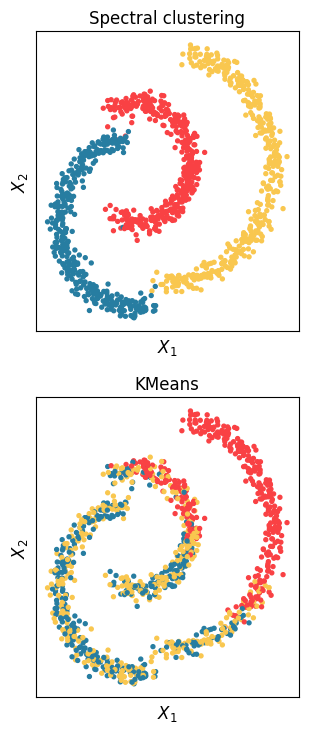

In [28]:
fig, ax = plt.subplots(2, 1, figsize=(3.25, 7.5))

ax[0].scatter(X[:, 0], X[:, 1], c=sp_labels, cmap=cmap, s=8)
ax[1].scatter(X[:, 0], X[:, 1], c=km_labels, cmap=cmap, s=8)

ax[0].set_title("Spectral clustering")
ax[1].set_title("KMeans")

for a in ax:
    a.set_xlabel(r"$X_1$")
    a.set_ylabel(r"$X_2$")
    a.grid(False)

    # Remove ticks and tick labels, keep spines/box
    a.set_xticks([])
    a.set_yticks([])
    a.tick_params(
        bottom=False,
        left=False,
        labelbottom=False,
        labelleft=False
    )

fig.tight_layout()
fig.savefig("./figures/fig1_c.pdf", bbox_inches="tight")
plt.show()